# 1.导入模块

In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

Batch_size = 128
LR = 1e-3
torch.manual_seed(42)
Latent_DIM = 20
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:",device)

device: cuda


# 2.数据加载 

In [60]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])
train_set = datasets.MNIST(root = './data', train = True, download = True, transform = transform)
test_set = datasets.MNIST(root = './data', train = False, download = True, transform = transform)
train_loader = DataLoader(train_set, batch_size = Batch_size, shuffle = True)
test_loader = DataLoader(test_set, batch_size = Batch_size, shuffle = False)
X, y = next(iter(train_loader))
print(X.shape, y.shape)

torch.Size([128, 784]) torch.Size([128])


# 3.编码器 Encoder

In [61]:
class Encoder(nn.Module):
    def __init__(self, input_dim = 784, hidden_dim = 256, laten_dim = Latent_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mu_ = nn.Linear(hidden_dim, laten_dim)
        self.logvar_ = nn.Linear(hidden_dim, laten_dim)

    def forward(self, X):
        h = self.net(X)
        return self.mu_(h), self.logvar_(h)

def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + std * eps

# 4.解码器 Decoder

In [62]:
class Decoder(nn.Module):
    def __init__(self, laten_dim = Latent_DIM, hidden_dim = 256, output_dim = 784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(laten_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z)

# 5.VAE

In [63]:
class VAE(nn.Module):
    def __init__(self, input_dim = 784, hidden_dim = 256, latent_dim = Latent_DIM):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def forward(self, X):
        mu, logvar = self.encoder(X)
        z = reparameterize(mu, logvar)
        X_hat = self.decoder(z)
        return X_hat, mu, logvar, z

# 6.Loss

In [64]:
def vae_loss(X_hat, X, mu, logvar):
    recon = F.binary_cross_entropy(X_hat, X, reduction = 'sum')  # 必须是 sum 
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl, recon, kl

# 7.训练循环

In [65]:
module = VAE().to(device)
optimizer = torch.optim.Adam(module.parameters(), lr = LR)
train_losses, recon_losses, kl_losses = [], [], []
epochs = 10
for epoch in range(epochs):
    module.train()
    total_recon, total_kl = 0.0, 0.0
    n_samples = 0
    for X, y in train_loader:
        X = X.to(device)
        X_hat, mu, logvar, z = module(X)
        loss, recon, kl = vae_loss(X_hat, X, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_recon += recon.item()
        total_kl += kl.item()
        n_samples += X.size(0)
    recon_avg, kl_avg = total_recon / n_samples, total_kl / n_samples
    train_losses.append(recon_avg + kl_avg)
    recon_losses.append(recon_avg)
    kl_losses.append(kl_avg)
    print(f'epoch {epoch+1:02d} | recon = {recon_avg:.2f} | kl = {kl_avg:.2f} | total = {recon_avg + kl_avg:.2f}')

epoch 01 | recon = 179.82 | kl = 6.54 | total = 186.36
epoch 02 | recon = 121.12 | kl = 13.47 | total = 134.59
epoch 03 | recon = 107.43 | kl = 15.53 | total = 122.96
epoch 04 | recon = 99.70 | kl = 17.07 | total = 116.76
epoch 05 | recon = 95.39 | kl = 17.79 | total = 113.19
epoch 06 | recon = 92.73 | kl = 18.22 | total = 110.95
epoch 07 | recon = 90.75 | kl = 18.58 | total = 109.34
epoch 08 | recon = 89.24 | kl = 18.84 | total = 108.08
epoch 09 | recon = 87.97 | kl = 19.08 | total = 107.04
epoch 10 | recon = 86.94 | kl = 19.28 | total = 106.22


# 8.曲线图

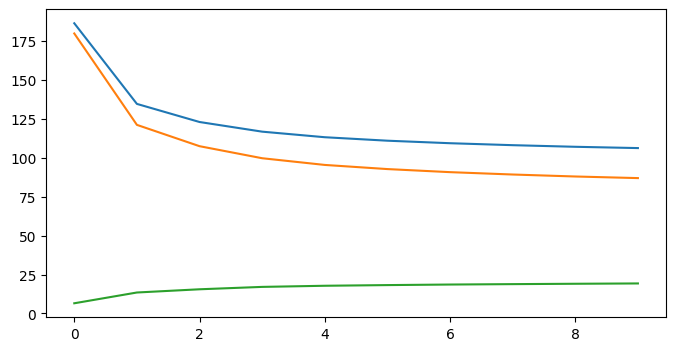

In [66]:
plt.figure(figsize = (8, 4))
plt.plot(train_losses, label = 'total')
plt.plot(recon_losses, label = 'recon')
plt.plot(kl_losses, label = 'kl')
plt.show()

# 9.Latent 可视化

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


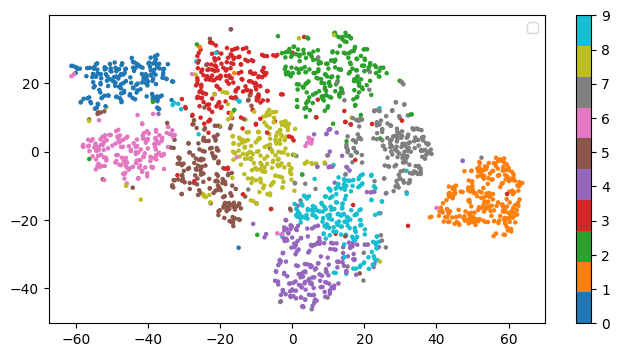

In [73]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(figsize = (8, 4))
module.eval()
with torch.no_grad():
    zs, ys = [], []   
    for x, y in test_loader:
        x = x.to(device)        
        _, mu, _, _ = module(x)  
        zs.append(mu.cpu())     
        ys.append(y)            
    Z = torch.cat(zs).numpy()
    Y = torch.cat(ys).numpy()
Z2 = TSNE(n_components = 2, random_state = 42).fit_transform(Z[:2000])  
plt.scatter(Z2[:, 0], Z2[:, 1], c= Y[:2000], cmap = 'tab10', s = 5)
plt.colorbar()
plt.legend()
plt.show()